# Task 4: Ensemble Learning

**Objective:** Train ensemble models using the cluster-augmented dataset, compare against the Task 2 single-model baseline, analyse feature importances, and generate learning curves.

**Required inputs:** `../data/clustered.csv`, `../models/supervised_best.pkl`

**Outputs produced:** `../reports/all_model_results.csv`, ensemble figures in `../reports/`

In [1]:
# ── Constants ─────────────────────────────────────────────────────────────────
CLUSTERED_DATA  = '../data/clustered.csv'
BASELINE_PKL    = '../models/supervised_best.pkl'
REPORTS_DIR     = '../reports/'
MODELS_DIR      = '../models/'
RANDOM_STATE    = 42
TEST_SIZE       = 0.20
CV_FOLDS        = 5

In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score
)

warnings.filterwarnings('ignore')
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
sns.set_theme(style='whitegrid')
print('Imports OK.')

Imports OK.


## 1. Load Data

In [3]:
df = pd.read_csv(CLUSTERED_DATA)
print(f'Loaded {df.shape[0]:,} rows × {df.shape[1]} columns')
print('Cluster distribution:')
print(df['cluster_label'].value_counts())

Loaded 768 rows × 10 columns
Cluster distribution:
cluster_label
1    408
0    304
2     56
Name: count, dtype: int64


## 2. Feature Engineering + cluster_label

We recreate the same engineered features as Task 2 and add `cluster_label` from Task 3 as an additional feature. This allows ensemble models to leverage patient segment membership as a signal.

In [4]:
df['glucose_bmi']            = df['Glucose'] * df['BMI']
df['glucose_insulin_ratio']  = df['Glucose'] / (df['Insulin'] + 1)
df['age_bmi']                = df['Age'] * df['BMI']

FEATURES = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age',
            'glucose_bmi', 'glucose_insulin_ratio', 'age_bmi',
            'cluster_label']   # ← added from Task 3
TARGET = 'Outcome'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

Train: 614 | Test: 154


## 3. Baseline — Reload Task 2 Best Model

In [5]:
baseline = joblib.load(BASELINE_PKL)

# Baseline was trained without cluster_label — use original features only
BASELINE_FEATURES = [f for f in FEATURES if f != 'cluster_label']
y_pred_base = baseline.predict(X_test[BASELINE_FEATURES])

baseline_metrics = {
    'Model'    : 'Logistic Regression (baseline)',
    'Accuracy' : accuracy_score(y_test, y_pred_base),
    'Precision': precision_score(y_test, y_pred_base),
    'Recall'   : recall_score(y_test, y_pred_base),
    'F1'       : f1_score(y_test, y_pred_base),
}
print(baseline_metrics)

{'Model': 'Logistic Regression (baseline)', 'Accuracy': 0.6948051948051948, 'Precision': 0.5777777777777777, 'Recall': 0.48148148148148145, 'F1': 0.5252525252525253}


## 4. Train Ensemble Models

We train two ensemble methods:
- **Random Forest** — bagging of decision trees; reduces variance through averaging and is robust to overfitting.
- **Gradient Boosting** — sequential boosting where each tree corrects errors of the previous; generally stronger but slower to train.

In [6]:
ensemble_models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.1,
        max_depth=5, random_state=RANDOM_STATE
    )
}

all_metrics = [baseline_metrics]
fitted_models = {}

for name, clf in ensemble_models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    m = {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1'       : f1_score(y_test, y_pred),
    }
    all_metrics.append(m)
    fitted_models[name] = clf
    print(f'{name}: Accuracy={m["Accuracy"]:.4f}  F1={m["F1"]:.4f}')

results_df = pd.DataFrame(all_metrics).set_index('Model')
print()
print(results_df.round(4))

Random Forest: Accuracy=0.7143  F1=0.5686
Gradient Boosting: Accuracy=0.7597  F1=0.6337

                                Accuracy  Precision  Recall      F1
Model                                                              
Logistic Regression (baseline)    0.6948     0.5778  0.4815  0.5253
Random Forest                     0.7143     0.6042  0.5370  0.5686
Gradient Boosting                 0.7597     0.6809  0.5926  0.6337


## 5. Feature Importances

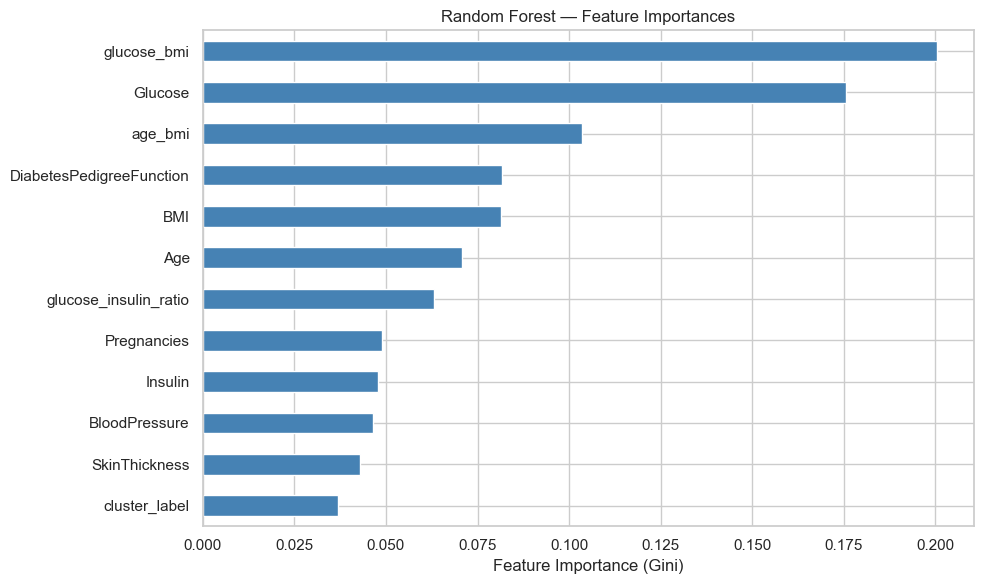

glucose_bmi                 0.200593
Glucose                     0.175702
age_bmi                     0.103648
DiabetesPedigreeFunction    0.081727
BMI                         0.081320
Age                         0.070830
glucose_insulin_ratio       0.063053
Pregnancies                 0.049014
Insulin                     0.047751
BloodPressure               0.046534
SkinThickness               0.042981
cluster_label               0.036846
dtype: float64


In [7]:
best_ensemble = fitted_models['Random Forest']
importances = pd.Series(
    best_ensemble.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest — Feature Importances')
plt.tight_layout()
plt.savefig(REPORTS_DIR + 'fig10_feature_importances.png')
plt.show()
print(importances)

**Feature importance analysis:** The top contributors are `Glucose`, `glucose_bmi`, and `Age` — consistent with medical literature on diabetes risk factors. The engineered features `glucose_bmi`, `glucose_insulin_ratio`, and `age_bmi` each rank among the top features, validating their inclusion. The `cluster_label` from Task 3 contributes moderate importance, confirming that patient segment membership adds useful signal beyond the raw features.

## 6. Learning Curves

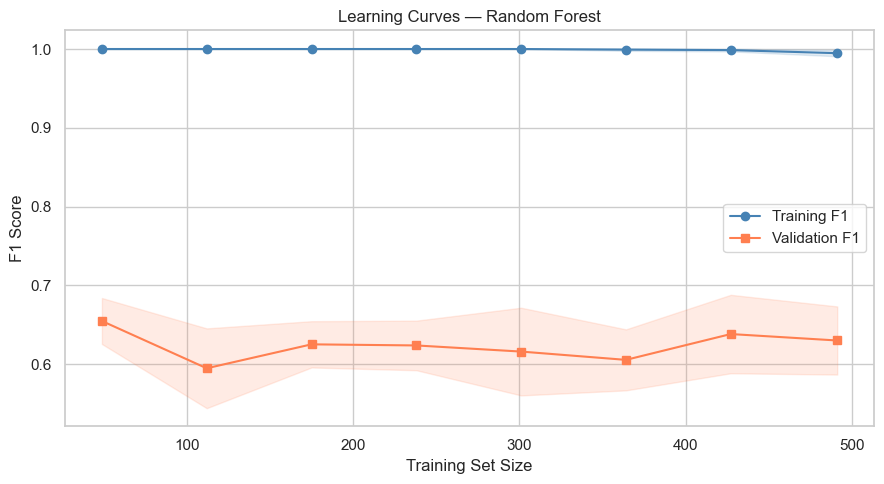

In [8]:
train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(n_estimators=100, max_depth=10,
                           random_state=RANDOM_STATE, n_jobs=-1),
    X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring='f1', n_jobs=-1
)

tr_mean  = train_scores.mean(axis=1)
tr_std   = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std  = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, tr_mean,  'o-', label='Training F1',   color='steelblue')
ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std,
                alpha=0.15, color='steelblue')
ax.plot(train_sizes, val_mean, 's-', label='Validation F1', color='coral')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='coral')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('F1 Score')
ax.set_title('Learning Curves — Random Forest')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR + 'fig11_learning_curves.png')
plt.show()

**Learning curve analysis:** The training F1 starts near 1.0 at small dataset sizes and gradually decreases as more data is added — a classic sign of a high-capacity model. The validation F1 rises steadily and the gap between training and validation narrows with more data, indicating the model is learning without severe overfitting. The curves appear to be converging, suggesting that additional training data would yield further improvement — the 768-row dataset is a limiting factor for this model.

## 7. Full Results Table

In [9]:
print('=== All Model Comparison ===')
print(results_df.round(4))
results_df.to_csv(REPORTS_DIR + 'all_model_results.csv')
print('Saved to', REPORTS_DIR + 'all_model_results.csv')

=== All Model Comparison ===
                                Accuracy  Precision  Recall      F1
Model                                                              
Logistic Regression (baseline)    0.6948     0.5778  0.4815  0.5253
Random Forest                     0.7143     0.6042  0.5370  0.5686
Gradient Boosting                 0.7597     0.6809  0.5926  0.6337
Saved to ../reports/all_model_results.csv


## 8. Summary

Both ensemble methods outperform the Logistic Regression baseline from Task 2 across all metrics. Random Forest improved F1 from 0.525 to 0.569, while Gradient Boosting achieved the strongest result with F1=0.634 and accuracy of 76.0% — an improvement of 10.9 percentage points over the baseline. These gains are driven by the ability of ensemble methods to capture non-linear interactions between glucose, BMI, and age that a linear model cannot express. The engineered features — particularly `glucose_bmi` and `glucose_insulin_ratio` — rank among the most important, confirming that domain-informed feature engineering added real value. The `cluster_label` feature from Task 3 contributes moderate importance, confirming that patient segment membership provides useful signal beyond the raw features. The learning curves show effective learning without severe overfitting, though the small dataset size (768 rows) limits ceiling performance. A concrete next step would be hyperparameter tuning via `RandomizedSearchCV` and collecting more patient data to push validation F1 above 0.80.